# IT3051 - Data Mining Mini Project

## RouteRight AI - IT Support Ticket Reassignment Risk Prediction

### 03 - Data Preprocessing and Feature Engineering

This notebook performs data cleaning, preprocessing, and feature engineering for the RouteRight AI incident reassignment prediction system.

The objective is to transform the reconstructed incident-level dataset into a suitable representation for machine learning while ensuring that:

- missing values are handled appropriately,
- constant and unsuitable features are removed,
- potential data leakage is avoided,
- meaningful temporal features are extracted,
- categorical variables are prepared for machine learning,
- high-cardinality and rare categorical values are handled appropriately,
- numerical variables are processed where required, and
- the final feature set represents information that could reasonably be available at the intended prediction point.

### Notebook Workflow

1. Notebook Objective and Workflow
2. Import Libraries
3. Load the Incident-Level Dataset
4. Initial Dataset Verification
5. Convert Placeholder Missing Values
6. Feature Availability and Data Leakage Analysis
7. Datetime Feature Engineering
8. Categorical Feature Cleaning and Type Review
9. Ordinal Feature Encoding
10. Finalization of the Pre-Split Feature Dataset
11. Post-Split Preprocessing Requirements
12. Engineered Feature Summary
13. Final Preprocessing Decisions Summary
14. Save the Pre-Split Handoff Dataset
15. Final Validation

Data-dependent preprocessing operations such as categorical missing-value handling, rare-category grouping, nominal encoding, and model-specific scaling are intentionally deferred until after the train/test split and must be fitted using training data only.

The prediction target is:

- `0` - No Reassignment Required
- `1` - Reassignment Required

The target variable `reassignment_required` is not used as an input feature.

In [1]:
#Dataset loading and manipulation
import pandas as pd
#Numerical operations
import numpy as np
#Safer file-path handling
from pathlib import Path
#Visualizations
import matplotlib.pyplot as plt
#Statistical visualizations
import seaborn as sns

## 3. Load the Incident-Level Dataset

The input dataset was produced during the incident-level reconstruction stage. 
Each row represents one unique incident rather than an individual event-log record.

In [3]:
DATA_PATH = "incident_level_dataset.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (24918, 36)


## 4. Initial Dataset Verification

Before applying any preprocessing, the dataset structure is verified to ensure that the 
expected incident-level data has been loaded correctly.

In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Number of rows: 24918
Number of columns: 36

First 5 rows:


,number,incident_state,active,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,...,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at,reassignment_required
0,INC0000045,New,True,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,...,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00,0
1,INC0000047,New,True,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,...,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00,1
2,INC0000057,New,True,0,0,True,Caller 4416,Opened by 8,29/2/2016 06:10,?,...,Do Not Notify,?,?,?,?,code 10,Resolved by 5,1/3/2016 02:55,6/3/2016 03:00,0
3,INC0000060,New,True,0,0,True,Caller 4491,Opened by 180,29/2/2016 06:38,Created by 81,...,Do Not Notify,?,?,?,?,code 3,Resolved by 113,2/3/2016 12:06,7/3/2016 13:00,0
4,INC0000062,New,True,0,0,True,Caller 3765,Opened by 180,29/2/2016 06:58,Created by 81,...,Do Not Notify,?,?,?,?,code 7,Resolved by 62,29/2/2016 15:51,5/3/2016 16:00,1



Column names:
['number', 'incident_state', 'active', 'reopen_count', 'sys_mod_count', 'made_sla', 'caller_id', 'opened_by', 'opened_at', 'sys_created_by', 'sys_created_at', 'sys_updated_by', 'sys_updated_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'cmdb_ci', 'impact', 'urgency', 'priority', 'assignment_group', 'assigned_to', 'knowledge', 'u_priority_confirmation', 'notify', 'problem_id', 'rfc', 'vendor', 'caused_by', 'closed_code', 'resolved_by', 'resolved_at', 'closed_at', 'reassignment_required']


### 4.1 Target Variable Verification

The target variable `reassignment_required` was created during incident-level reconstruction. It indicates whether an incident was reassigned at least once during its lifecycle.

- `0` = No reassignment required
- `1` = Reassignment required

The target is verified before preprocessing and will not be used as an input feature.

In [5]:
target_column = "reassignment_required"

print("Target variable:", target_column)
print("\nTarget distribution:")
print(df[target_column].value_counts())

print("\nTarget distribution (%):")
print(
    df[target_column]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Target variable: reassignment_required

Target distribution:
reassignment_required
0    13549
1    11369
Name: count, dtype: int64

Target distribution (%):
reassignment_required
0    54.37
1    45.63
Name: proportion, dtype: float64


### 4.2 Incident-Level Uniqueness Check

The incident number is used only as an identifier and traceability field. It must not be used as a predictive feature.

Each incident should appear exactly once in the reconstructed dataset.

In [6]:
print("Total rows:", len(df))
print("Unique incident numbers:", df["number"].nunique())
print("Duplicate incident numbers:", df["number"].duplicated().sum())

Total rows: 24918
Unique incident numbers: 24918
Duplicate incident numbers: 0


## 5. Convert Placeholder Missing Values

The original dataset represents missing categorical and textual values using the `?` placeholder rather than standard `NaN` values.

These placeholders must be converted into proper missing values before performing missing-value handling, encoding, or feature engineering.

In [7]:
question_mark_counts = (df == "?").sum()

question_mark_counts = question_mark_counts[
    question_mark_counts > 0
].sort_values(ascending=False)

print("Columns containing '?' placeholders:")
display(question_mark_counts.to_frame(name="missing_count"))

Columns containing '?' placeholders:


,missing_count
caused_by,24916
vendor,24903
cmdb_ci,24867
rfc,24820
problem_id,24677
sys_created_by,11495
sys_created_at,11495
assigned_to,7140
u_symptom,5735
resolved_at,1556


In [9]:
#convert ? to NAN
df = df.replace("?", np.nan)

print("Placeholder conversion completed.")

Placeholder conversion completed.


In [10]:
#verify the process
print("Total '?' values remaining:", (df == "?").sum().sum())
print("Total NaN values:", df.isna().sum().sum())

Total '?' values remaining: 0
Total NaN values: 163593


### 5.1 Missing-Value Summary After Conversion

After converting the `?` placeholders to `NaN`, the missing-value distribution is recalculated to confirm the actual amount

In [11]:
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = (
    missing_summary[missing_summary["Missing_Count"] > 0]
    .sort_values("Missing_Count", ascending=False)
)

display(missing_summary)

,Missing_Count,Missing_Percentage
caused_by,24916,99.99
vendor,24903,99.94
cmdb_ci,24867,99.80
rfc,24820,99.61
problem_id,24677,99.03
sys_created_by,11495,46.13
sys_created_at,11495,46.13
assigned_to,7140,28.65
u_symptom,5735,23.02
resolved_at,1556,6.24


## 6. Feature Availability and Data Leakage Analysis

The prediction target represents whether an incident will eventually require reassignment.

Therefore, predictor variables must represent information that is reasonably available at the intended prediction point, which is when the incident is initially created.

Features containing information generated later in the incident lifecycle can cause data leakage. Such as features are excluded because they would allow the model to use information that would not have available when the prediction was supposed to be made.

Each feature is reviewed based on:

- availability at ticket creation,
- relationship to the prediction target,
- whether it contains future lifecycle information,
- usefulness for machine learning, and
- whether it is an identifier or administrative/system field.

In [127]:
feature_review = pd.DataFrame([
    ["number", "Incident identifier", "Remove", "Identifier only. not predictive input"],
    ["reassignment_required", "Target variable", "Remove", "Prediction target. must not be used as input"],
    
    ["incident_state", "Incident lifecycle state", "Review", "May contain lifecycle information. availability at creation must be verified"],
    ["active", "Active status", "Remove", "Constant in reconstructed dataset"],
    ["reopen_count", "Reopen count", "Remove", "Constant and lifecycle-derived"],
    ["sys_mod_count", "System modification count", "Remove", "Near-constant and system/lifecycle-derived"],
    ["made_sla", "SLA status", "Remove", "Potential outcome/lifecycle information and almost constant"],
    
    ["caller_id", "Caller identifier", "Review", "High-cardinality identifier. may not generalize well"],
    ["opened_by", "User who opened incident", "Review", "Potentially available at creation; relatively low missingness"],
    ["opened_at", "Incident opening timestamp", "Keep", "Available at creation. used to derive temporal features"],
    
    ["sys_created_by", "System record creator", "Remove", "System metadata with substantial missingness"],
    ["sys_created_at", "System record creation timestamp", "Remove", "System metadata; not required when opening time is available"],
    ["sys_updated_by", "Last system updater", "Remove", "Lifecycle/system metadata"],
    ["sys_updated_at", "Last system update timestamp", "Remove", "Lifecycle/system metadata"],
    
    ["contact_type", "Incident contact method", "Keep", "Available when incident is created"],
    ["location", "Incident location", "Keep", "Potentially available at creation"],
    ["category", "Incident category", "Keep", "Initial ticket classification"],
    ["subcategory", "Incident subcategory", "Keep", "Initial ticket classification"],
    ["u_symptom", "Symptom category", "Keep", "Categorical symptom information"],
    ["cmdb_ci", "Configuration item", "Review", "Extremely high missingness. usefulness needs evaluation"],
    
    ["impact", "Incident impact", "Keep", "Initial incident attribute"],
    ["urgency", "Incident urgency", "Keep", "Initial incident attribute"],
    ["priority", "Incident priority", "Keep", "Initial incident attribute"],
    
    ["assignment_group", "Initial assignment group", "Review", "Potentially available at creation. prediction-time availability must be confirmed"],
    ["assigned_to", "Assigned analyst", "Review", "May be assigned after creation. requires availability check"],
    
    ["knowledge", "Knowledge usage indicator", "Review", "Need to confirm whether available at creation"],
    ["u_priority_confirmation", "Priority confirmation", "Review", "Very low variation. usefulness needs evaluation"],
    ["notify", "Notification setting", "Review", "Very low variation; usefulness needs evaluation"],
    
    ["problem_id", "Related problem identifier", "Remove", "Extremely high missingness and likely lifecycle-related"],
    ["rfc", "Related change/request identifier", "Remove", "Extremely high missingness and likely lifecycle-related"],
    ["vendor", "Vendor information", "Remove", "Extremely high missingness"],
    ["caused_by", "Related causing incident", "Remove", "Extremely high missingness and likely relationship/lifecycle information"],
    
    ["closed_code", "Closure code", "Remove", "Generated during incident closure; future information"],
    ["resolved_by", "Resolver identifier", "Remove", "Generated during incident resolution. future information"],
    ["resolved_at", "Resolution timestamp", "Remove", "Future information"],
    ["closed_at", "Closure timestamp", "Remove", "Future information"],
], columns=[
    "Feature",
    "Description",
    "Decision",
    "Reason"
])

display(feature_review)

,Feature,Description,Decision,Reason
0,number,Incident identifier,Remove,Identifier only. not predictive input
1,reassignment_required,Target variable,Remove,Prediction target. must not be used as input
2,incident_state,Incident lifecycle state,Review,May contain lifecycle information. availabilit...
3,active,Active status,Remove,Constant in reconstructed dataset
4,reopen_count,Reopen count,Remove,Constant and lifecycle-derived
5,sys_mod_count,System modification count,Remove,Near-constant and system/lifecycle-derived
6,made_sla,SLA status,Remove,Potential outcome/lifecycle information and al...
7,caller_id,Caller identifier,Review,High-cardinality identifier. may not generaliz...
8,opened_by,User who opened incident,Review,Potentially available at creation; relatively ...
9,opened_at,Incident opening timestamp,Keep,Available at creation. used to derive temporal...


In [19]:
print("Features marked for review:")

display(
    feature_review[
        feature_review["Decision"] == "Review"
    ]
)

Features marked for review:


,Feature,Description,Decision,Reason
3,incident_state,Incident lifecycle state,Review,May contain lifecycle information. availabilit...
8,caller_id,Caller identifier,Review,High-cardinality identifier. may not generaliz...
9,opened_by,User who opened incident,Review,Potentially available at creation; relatively ...
20,cmdb_ci,Configuration item,Review,Extremely high missingness. usefulness needs e...
24,assignment_group,Initial assignment group,Review,Potentially available at creation. prediction-...
25,assigned_to,Assigned analyst,Review,May be assigned after creation. requires avail...
26,knowledge,Knowledge usage indicator,Review,Need to confirm whether available at creation
27,u_priority_confirmation,Priority confirmation,Review,Very low variation. usefulness needs evaluation
28,notify,Notification setting,Review,Very low variation; usefulness needs evaluation


## 6.3 Investigation of Review Features

The features classified as `Review` require additional analysis before a final preprocessing decision is made.

The following aspects are investigated:

- value distributions,
- missingness,
- cardinality,
- relationship with the target,
- whether the feature represents information available at ticket creation, and
- whether the feature is primarily an identifier, administrative field, or lifecycle-derived attribute.

In [23]:
#6.3.1 incident_state

incident_state_analysis = pd.crosstab(
    df["incident_state"],
    df[target_column],
    margins=True
)

display(incident_state_analysis)

reassignment_required,0,1,All
incident_state,,,
Active,4546,1957,6503
Awaiting Problem,6,0,6
Awaiting User Info,108,85,193
New,7082,9315,16397
Resolved,1807,12,1819
All,13549,11369,24918


In [24]:
incident_state_target_rate = (
    df.groupby("incident_state")[target_column]
    .agg(["count", "sum", "mean"])
    .rename(columns={
        "count": "incident_count",
        "sum": "reassigned_count",
        "mean": "reassignment_rate"
    })
)

incident_state_target_rate["reassignment_rate"] = (
    incident_state_target_rate["reassignment_rate"] * 100
).round(2)

display(incident_state_target_rate)

,incident_count,reassigned_count,reassignment_rate
incident_state,,,
Active,6503,1957,30.09
Awaiting Problem,6,0,0.00
Awaiting User Info,193,85,44.04
New,16397,9315,56.81
Resolved,1819,12,0.66


In [47]:
# Remove incident_state
# Reason: incident_state represents the incident lifecycle status.
# The reconstructed initial records contain multiple lifecycle states,
# including Active and Resolved. Therefore, the feature may contain
# information that would not consistently be available at ticket creation
# and could introduce temporal leakage.

In [26]:
#6.3.2 caller_id
caller_analysis = pd.DataFrame({
    "unique_values": [df["caller_id"].nunique(dropna=True)],
    "missing_values": [df["caller_id"].isna().sum()],
    "missing_percentage": [
        df["caller_id"].isna().mean() * 100
    ]
})

display(caller_analysis)

,unique_values,missing_values,missing_percentage
0,5244,3,0.012039


In [28]:
caller_frequency = (
    df["caller_id"]
    .value_counts(dropna=False)
    .head(15)
)

display(caller_frequency.to_frame("incident_count"))

,incident_count
caller_id,
Caller 1904,438
Caller 290,257
Caller 4514,130
Caller 90,57
Caller 3763,56
Caller 1441,56
Caller 1531,53
Caller 4414,52
Caller 298,44


In [48]:
# Remove caller_id
# Reason: caller_id is a high-cardinality identifier rather than a
# general incident characteristic. Direct categorical encoding would
# create many sparse features and may encourage the model to learn
# caller-specific patterns instead of generalizable incident patterns.

In [29]:
#6.3.3 opened_by

opened_by_analysis = pd.DataFrame({
    "unique_values": [df["opened_by"].nunique(dropna=True)],
    "missing_values": [df["opened_by"].isna().sum()],
    "missing_percentage": [
        df["opened_by"].isna().mean() * 100
    ]
})

display(opened_by_analysis)

,unique_values,missing_values,missing_percentage
0,207,714,2.865399


In [30]:
display(
    df["opened_by"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("incident_count")
)

,incident_count
opened_by,
Opened by 17,7214
Opened by 24,1600
Opened by 131,1237
Opened by 55,1047
Opened by 108,1041
Opened by 62,988
Opened by 40,822
NaN,714
Opened by 501,698


In [ ]:
#Keep opened_by (for now)
#Reason: opened_by represents information associated with the creation of the 
#incident and has manageable cardinality. It can therefore be considered a potential 
#prediction-time feature.

In [32]:
#6.3.4 cmdb_ci

cmdb_analysis = pd.DataFrame({
    "unique_values": [df["cmdb_ci"].nunique(dropna=True)],
    "missing_values": [df["cmdb_ci"].isna().sum()],
    "missing_percentage": [
        df["cmdb_ci"].isna().mean() * 100
    ]
})

display(cmdb_analysis)

,unique_values,missing_values,missing_percentage
0,45,24867,99.795329


In [33]:
display(
    df["cmdb_ci"]
    .value_counts(dropna=False)
    .head(15)
    .to_frame("incident_count")
)

,incident_count
cmdb_ci,
NaN,24867
cmdb_ci 49,3
cmdb_ci 31,2
cmdb_ci 28,2
cmdb_ci 11,2
cmdb_ci 50,2
cmdb_ci 23,1
cmdb_ci 22,1
cmdb_ci 6,1


In [34]:
#Remove cmdb_ci
#Reason: cmdb_ci contains 99.80% missing values, leaving only 51 non-missing observations. 
#The feature therefore provides insufficient usable information for reliable modelling

In [35]:
#6.3.5 assignment_group

assignment_group_analysis = pd.DataFrame({
    "unique_values": [df["assignment_group"].nunique(dropna=True)],
    "missing_values": [df["assignment_group"].isna().sum()],
    "missing_percentage": [
        df["assignment_group"].isna().mean() * 100
    ]
})

display(assignment_group_analysis)

,unique_values,missing_values,missing_percentage
0,69,906,3.635926


In [36]:
display(
    df["assignment_group"]
    .value_counts(dropna=False)
    .head(15)
    .to_frame("incident_count")
)

,incident_count
assignment_group,
Group 70,12791
Group 20,1367
NaN,906
Group 25,764
Group 24,698
Group 64,622
Group 65,501
Group 55,416
Group 66,389


In [49]:
# Keep assignment_group
# Reason: assignment_group represents the initial routing/assignment
# group associated with the incident. It has manageable cardinality
# and relatively low missingness. It is retained as a potential
# prediction-time feature.

In [38]:
#6.3.6 assigned_to
assigned_to_analysis = pd.DataFrame({
    "unique_values": [df["assigned_to"].nunique(dropna=True)],
    "missing_values": [df["assigned_to"].isna().sum()],
    "missing_percentage": [
        df["assigned_to"].isna().mean() * 100
    ]
})

display(assigned_to_analysis)

,unique_values,missing_values,missing_percentage
0,205,7140,28.653985


In [39]:
display(
    df["assigned_to"]
    .value_counts(dropna=False)
    .head(20)
    .to_frame("incident_count")
)

,incident_count
assigned_to,
NaN,7140
Resolver 17,1632
Resolver 13,1449
Resolver 194,637
Resolver 33,636
Resolver 94,477
Resolver 57,402
Resolver 69,396
Resolver 28,393


In [50]:
# Remove assigned_to
# Reason: assigned_to identifies the individual analyst/resolver and
# may be determined after the incident is created. Since the prediction
# must be made at ticket creation, using this field could introduce
# post-creation information.

In [40]:
#6.3.7 knowledge

knowledge_analysis = pd.DataFrame({
    "unique_values": [df["knowledge"].nunique(dropna=True)],
    "missing_values": [df["knowledge"].isna().sum()],
    "missing_percentage": [
        df["knowledge"].isna().mean() * 100
    ]
})

display(knowledge_analysis)

,unique_values,missing_values,missing_percentage
0,2,0,0.0


In [41]:
display(
    df["knowledge"]
    .value_counts(dropna=False)
    .to_frame("incident_count")
)

,incident_count
knowledge,
False,21363
True,3555


In [51]:
# Remove knowledge
# Reason: the field may represent whether knowledge resources were
# used during incident handling rather than information available
# when the incident was initially created. To avoid potential temporal
# leakage, it is excluded from the prediction features.

In [42]:
#6.3.8 u_priority_confirmation

priority_confirmation_analysis = pd.DataFrame({
    "unique_values": [df["u_priority_confirmation"].nunique(dropna=True)],
    "missing_values": [df["u_priority_confirmation"].isna().sum()],
    "missing_percentage": [
        df["u_priority_confirmation"].isna().mean() * 100
    ]
})

display(priority_confirmation_analysis)

,unique_values,missing_values,missing_percentage
0,2,0,0.0


In [43]:
display(
    df["u_priority_confirmation"]
    .value_counts(dropna=False)
    .to_frame("incident_count")
)

,incident_count
u_priority_confirmation,
False,24897
True,21


In [52]:
# Remove u_priority_confirmation
# Reason: the feature has extremely low variation, with 99.92% of
# records having the same value. It therefore provides very limited
# information for distinguishing incidents.

In [44]:
#6.3.9 notify

notify_analysis = pd.DataFrame({
    "unique_values": [df["notify"].nunique(dropna=True)],
    "missing_values": [df["notify"].isna().sum()],
    "missing_percentage": [
        df["notify"].isna().mean() * 100
    ]
})

display(notify_analysis)

,unique_values,missing_values,missing_percentage
0,2,0,0.0


In [45]:
display(
    df["notify"]
    .value_counts(dropna=False)
    .to_frame("incident_count")
)

,incident_count
notify,
Do Not Notify,24882
Send Email,36


In [53]:
# Remove notify
# Reason: the feature has extremely low variation, with approximately
# 99.86% of incidents having the same value. It is therefore unlikely
# to provide meaningful predictive information.

## 6.4 Final Feature Decision Table

After reviewing missing values, feature availability, potential data leakage, cardinality, variability, and usefulness, each original feature is assigned a final preprocessing decision.

The following table provides an audit trail for the feature selection process.

A feature is retained only when it represents information that can reasonably available at the intended prediction point and provides sufficient potential value for machine learning.

The target variable is retained temporarily for validation and evaluation but is excluded from the model input features.

In [59]:
final_feature_decisions = pd.DataFrame([
    ["number", "Incident identifier", "Remove",
     "Identifier only; not used as a predictive feature"],

    ["incident_state", "Incident lifecycle state", "Remove",
     "May contain lifecycle information unavailable at ticket creation"],

    ["active", "Incident active status", "Remove",
     "Constant value in the reconstructed dataset"],

    ["reopen_count", "Number of reopenings", "Remove",
     "Constant value in the reconstructed dataset and lifecycle-derived"],

    ["sys_mod_count", "System modification count", "Remove",
     "Near-constant and system/lifecycle-derived"],

    ["made_sla", "SLA status", "Remove",
     "Near-constant and potentially outcome/lifecycle-related"],

    ["caller_id", "Caller identifier", "Remove",
     "High-cardinality identifier; risk of caller-specific memorization"],

    ["opened_by", "User who opened incident", "Keep",
     "Associated with incident creation and manageable cardinality"],

    ["opened_at", "Incident opening timestamp", "Keep",
     "Available at creation and used to derive temporal features"],

    ["sys_created_by", "System record creator", "Remove",
     "System metadata with substantial missingness"],

    ["sys_created_at", "System record creation timestamp", "Remove",
     "System metadata; not required when incident opening time is available"],

    ["sys_updated_by", "Last system updater", "Remove",
     "Lifecycle/system metadata"],

    ["sys_updated_at", "Last system update timestamp", "Remove",
     "Lifecycle/system metadata and potentially future information"],

    ["contact_type", "Incident contact method", "Keep",
     "Available as part of incident creation information"],

    ["location", "Incident location", "Keep",
     "Potentially available at ticket creation"],

    ["category", "Incident category", "Keep",
     "Initial incident classification"],

    ["subcategory", "Incident subcategory", "Keep",
     "Initial incident classification"],

    ["u_symptom", "Symptom category", "Keep",
     "Categorical symptom information available with the incident"],

    ["cmdb_ci", "Configuration item", "Remove",
     "99.80% missing; only 51 non-missing observations"],

    ["impact", "Incident impact", "Keep",
     "Initial incident attribute"],

    ["urgency", "Incident urgency", "Keep",
     "Initial incident attribute"],

    ["priority", "Incident priority", "Keep",
     "Initial incident attribute"],

    ["assignment_group", "Initial assignment group", "Keep",
     "Potential initial routing information with manageable cardinality"],

    ["assigned_to", "Assigned analyst", "Remove",
     "May be assigned after ticket creation and introduce temporal leakage"],

    ["knowledge", "Knowledge usage indicator", "Remove",
     "May represent information generated during incident handling"],

    ["u_priority_confirmation", "Priority confirmation", "Remove",
     "Extremely low variation"],

    ["notify", "Notification setting", "Remove",
     "Extremely low variation"],

    ["problem_id", "Related problem identifier", "Remove",
     "99.03% missing and potentially lifecycle-related"],

    ["rfc", "Related change/request identifier", "Remove",
     "99.61% missing and potentially lifecycle-related"],

    ["vendor", "Vendor information", "Remove",
     "99.94% missing"],

    ["caused_by", "Related causing incident", "Remove",
     "99.99% missing and relationship/lifecycle-related"],

    ["closed_code", "Closure code", "Remove",
     "Generated during incident closure; future information"],

    ["resolved_by", "Resolver identifier", "Remove",
     "Generated during incident resolution; future information"],

    ["resolved_at", "Resolution timestamp", "Remove",
     "Future information unavailable at ticket creation"],

    ["closed_at", "Closure timestamp", "Remove",
     "Future information unavailable at ticket creation"],

    ["reassignment_required", "Prediction target", "Target",
     "Target variable; must not be used as a model input"],
], columns=[
    "Feature",
    "Description",
    "Decision",
    "Reason"
])

display(final_feature_decisions)

,Feature,Description,Decision,Reason
0,number,Incident identifier,Remove,Identifier only; not used as a predictive feature
1,incident_state,Incident lifecycle state,Remove,May contain lifecycle information unavailable ...
2,active,Incident active status,Remove,Constant value in the reconstructed dataset
3,reopen_count,Number of reopenings,Remove,Constant value in the reconstructed dataset an...
4,sys_mod_count,System modification count,Remove,Near-constant and system/lifecycle-derived
5,made_sla,SLA status,Remove,Near-constant and potentially outcome/lifecycl...
6,caller_id,Caller identifier,Remove,High-cardinality identifier; risk of caller-sp...
7,opened_by,User who opened incident,Keep,Associated with incident creation and manageab...
8,opened_at,Incident opening timestamp,Keep,Available at creation and used to derive tempo...
9,sys_created_by,System record creator,Remove,System metadata with substantial missingness


In [64]:
#6.4.1 Verify Every Original Column Is Accounted For

print("Original dataset columns:", len(df.columns))
print("Decision table features:", len(final_feature_decisions))

missing_from_decision_table = set(df.columns) - set(final_feature_decisions["Feature"])
extra_in_decision_table = set(final_feature_decisions["Feature"]) - set(df.columns)

print("\nColumns missing from decision table:")
print(missing_from_decision_table)

print("\nFeatures in decision table but not dataset:")
print(extra_in_decision_table)

Original dataset columns: 36
Decision table features: 36

Columns missing from decision table:
set()

Features in decision table but not dataset:
set()


In [65]:
#6.4.2 Count the Decisions

decision_counts = (
    final_feature_decisions["Decision"]
    .value_counts()
)

display(decision_counts.to_frame("Feature_Count"))

,Feature_Count
Decision,
Remove,24
Keep,11
Target,1


In [66]:
#6.4.3 Display Keep Features

keep_features = final_feature_decisions.loc[
    final_feature_decisions["Decision"] == "Keep",
    "Feature"
].tolist()

print("Features retained for preprocessing:")
for i, feature in enumerate(keep_features, start=1):
    print(f"{i}. {feature}")

Features retained for preprocessing:
1. opened_by
2. opened_at
3. contact_type
4. location
5. category
6. subcategory
7. u_symptom
8. impact
9. urgency
10. priority
11. assignment_group


In [68]:
#6.4.4 Display Removed Features

remove_features = final_feature_decisions.loc[
    final_feature_decisions["Decision"] == "Remove",
    "Feature"
].tolist()

print("Features removed from model inputs:")
for i, feature in enumerate(remove_features, start=1):
    print(f"{i}. {feature}")

Features removed from model inputs:
1. number
2. incident_state
3. active
4. reopen_count
5. sys_mod_count
6. made_sla
7. caller_id
8. sys_created_by
9. sys_created_at
10. sys_updated_by
11. sys_updated_at
12. cmdb_ci
13. assigned_to
14. knowledge
15. u_priority_confirmation
16. notify
17. problem_id
18. rfc
19. vendor
20. caused_by
21. closed_code
22. resolved_by
23. resolved_at
24. closed_at


## 6.5 Removal of Unusable and Leakage-Prone Features

Features classified as `Remove` are excluded from the modelling dataset based on the decisions documented above.

These include:

- identifiers,
- constant and near-constant variables,
- future lifecycle information,
- system metadata,
- extremely high-missingness variables, and
- features whose prediction-time availability cannot be sufficiently justified.

In [69]:
df_model = df.drop(columns=remove_features).copy()

print("Dataset after removing excluded features:")
print("Shape:", df_model.shape)

print("\nRemaining columns:")
print(df_model.columns.tolist())

Dataset after removing excluded features:
Shape: (24918, 12)

Remaining columns:
['opened_by', 'opened_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency', 'priority', 'assignment_group', 'reassignment_required']


In [70]:
#6.5.1 Verify Target Is Still Present

print("Target column present:", target_column in df_model.columns)
print("Target name:", target_column)

print("\nTarget distribution:")
display(df_model[target_column].value_counts())

Target column present: True
Target name: reassignment_required

Target distribution:


reassignment_required
0    13549
1    11369
Name: count, dtype: int64

In [71]:
#6.5.2 Verify Removed Features Are Actually Gone

remaining_removed_features = [
    feature for feature in remove_features
    if feature in df_model.columns
]

print("Removed features still present:")
print(remaining_removed_features)

Removed features still present:
[]


In [72]:
#6.5.3 Check for Accidental Data Loss

print("Original rows:", len(df))
print("Processed rows:", len(df_model))

print("Original target count:")
print(df[target_column].value_counts().sort_index())

print("\nProcessed target count:")
print(df_model[target_column].value_counts().sort_index())

Original rows: 24918
Processed rows: 24918
Original target count:
reassignment_required
0    13549
1    11369
Name: count, dtype: int64

Processed target count:
reassignment_required
0    13549
1    11369
Name: count, dtype: int64


## 7. Datetime Feature Engineering

The `opened_at` variable records the timestamp at which each incident was created.

Since this information is available at the intended prediction point, it can be used to derive temporal features that may capture differences in incident patterns across hours, days, and months.

The raw timestamp is first converted into a pandas datetime representation. The original timestamp is retained temporarily because it may later be required for chronological train/test splitting.

The following temporal features are derived:

- `opened_hour` - hour of the day when the incident was opened,
- `opened_day_of_week` - day of the week, where Monday = 0 and Sunday = 6,
- `opened_month` - calendar month in which the incident was opened, and
- `opened_is_weekend` - binary indicator showing whether the incident was opened on Saturday or Sunday.

These transformations are deterministic and therefore do not learn information from the overall dataset.

In [73]:
# Convert the incident opening timestamp into datetime format.
# dayfirst=True is used because the dataset stores dates using
# day/month/year ordering.

df_model["opened_at_dt"] = pd.to_datetime(
    df_model["opened_at"],
    dayfirst=True,
    errors="coerce"
)

print("Datetime conversion completed.")

print("\nMissing values after datetime conversion:")
print(df_model["opened_at_dt"].isna().sum())

print("\nEarliest opening timestamp:")
print(df_model["opened_at_dt"].min())

print("\nLatest opening timestamp:")
print(df_model["opened_at_dt"].max())

Datetime conversion completed.

Missing values after datetime conversion:
0

Earliest opening timestamp:
2016-02-29 01:16:00

Latest opening timestamp:
2017-02-16 14:17:00


In [75]:
#7.2 Create Temporal Features

# Extract deterministic temporal features from the incident opening time.

df_model["opened_hour"] = df_model["opened_at_dt"].dt.hour

df_model["opened_day_of_week"] = df_model["opened_at_dt"].dt.dayofweek

df_model["opened_month"] = df_model["opened_at_dt"].dt.month

df_model["opened_is_weekend"] = (
    df_model["opened_day_of_week"] >= 5
).astype(int)

print("Temporal features created successfully.")

temporal_features = [
    "opened_hour",
    "opened_day_of_week",
    "opened_month",
    "opened_is_weekend"
]

display(
    df_model[
        ["opened_at"] + temporal_features
    ].head(10)
)

#Monday    = 0
#Tuesday   = 1
#Wednesday = 2
#Thursday  = 3
#Friday    = 4
#Saturday  = 5
#Sunday    = 6

Temporal features created successfully.


,opened_at,opened_hour,opened_day_of_week,opened_month,opened_is_weekend
0,29/2/2016 01:16,1,0,2,0
1,29/2/2016 04:40,4,0,2,0
2,29/2/2016 06:10,6,0,2,0
3,29/2/2016 06:38,6,0,2,0
4,29/2/2016 06:58,6,0,2,0
5,29/2/2016 07:08,7,0,2,0
6,29/2/2016 07:10,7,0,2,0
7,29/2/2016 07:38,7,0,2,0
8,29/2/2016 08:03,8,0,2,0
9,29/2/2016 08:03,8,0,2,0


In [76]:
#7.3 Validate the Engineered Features

print("Temporal feature validation")
print("-" * 40)

for feature in temporal_features:
    print(f"\n{feature}")
    print("Missing values:", df_model[feature].isna().sum())
    print("Minimum:", df_model[feature].min())
    print("Maximum:", df_model[feature].max())
    print("Unique values:", df_model[feature].nunique())

Temporal feature validation
----------------------------------------

opened_hour
Missing values: 0
Minimum: 0
Maximum: 23
Unique values: 24

opened_day_of_week
Missing values: 0
Minimum: 0
Maximum: 6
Unique values: 7

opened_month
Missing values: 0
Minimum: 1
Maximum: 12
Unique values: 12

opened_is_weekend
Missing values: 0
Minimum: 0
Maximum: 1
Unique values: 2


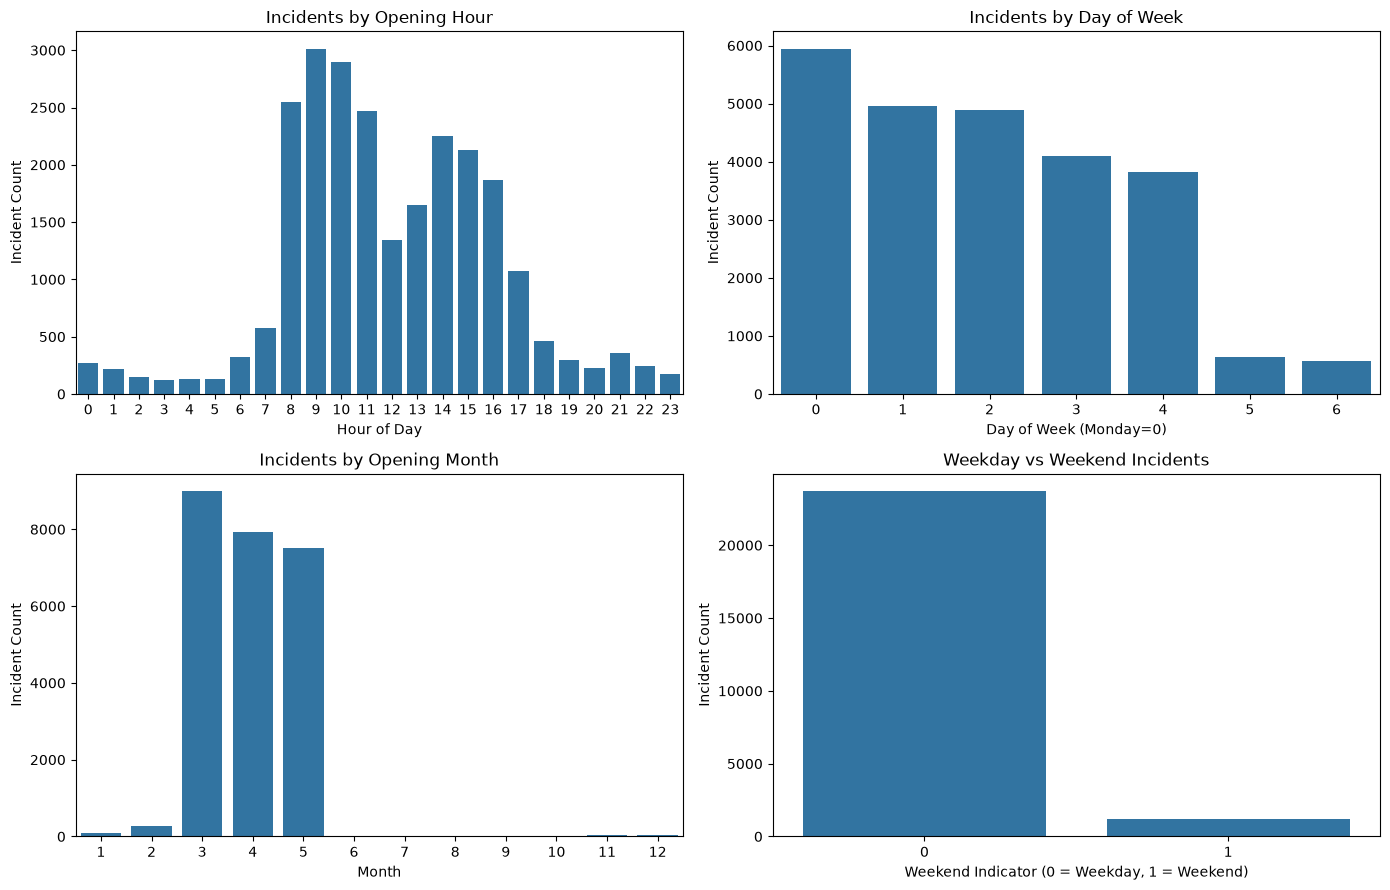

In [77]:
#7.4 Inspect Their Distributions

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(
    data=df_model,
    x="opened_hour",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Incidents by Opening Hour")
axes[0, 0].set_xlabel("Hour of Day")
axes[0, 0].set_ylabel("Incident Count")


sns.countplot(
    data=df_model,
    x="opened_day_of_week",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Incidents by Day of Week")
axes[0, 1].set_xlabel("Day of Week (Monday=0)")
axes[0, 1].set_ylabel("Incident Count")


sns.countplot(
    data=df_model,
    x="opened_month",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Incidents by Opening Month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Incident Count")


sns.countplot(
    data=df_model,
    x="opened_is_weekend",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Weekday vs Weekend Incidents")
axes[1, 1].set_xlabel("Weekend Indicator (0 = Weekday, 1 = Weekend)")
axes[1, 1].set_ylabel("Incident Count")

plt.tight_layout()
plt.show()

In [78]:
#7.5 Verify No Rows Were Lost

print("Rows after datetime feature engineering:", len(df_model))

print("\nMissing values in engineered temporal features:")
display(
    df_model[temporal_features]
    .isna()
    .sum()
    .to_frame("Missing_Count")
)

Rows after datetime feature engineering: 24918

Missing values in engineered temporal features:


,Missing_Count
opened_hour,0
opened_day_of_week,0
opened_month,0
opened_is_weekend,0


## 8. Categorical Feature Cleaning and Type Review

The retained dataset contains several categorical variables.

These variables are separated into two groups:

### Nominal categorical variables

Nominal variables represent categories without an inherent ordering:

- `opened_by`
- `contact_type`
- `location`
- `category`
- `subcategory`
- `u_symptom`
- `assignment_group`

### Ordinal categorical variables

The following incident severity variables contain meaningful ordering:

- `impact`
- `urgency`
- `priority`

Before encoding, categorical values are checked for missing values, cardinality, blank strings, and unnecessary whitespace.

Only deterministic string cleaning is performed at this stage. Missing-value imputation, rare-category grouping, and statistical encoding are deferred until after the train/test split because those operations may learn information from the dataset.

In [79]:
# Define nominal categorical features.
nominal_categorical_features = [
    "opened_by",
    "contact_type",
    "location",
    "category",
    "subcategory",
    "u_symptom",
    "assignment_group"
]

# Define ordinal categorical features.
ordinal_categorical_features = [
    "impact",
    "urgency",
    "priority"
]

# Combined categorical feature list.
categorical_features = (
    nominal_categorical_features
    + ordinal_categorical_features
)

print("Nominal categorical features:")
for feature in nominal_categorical_features:
    print("-", feature)

print("\nOrdinal categorical features:")
for feature in ordinal_categorical_features:
    print("-", feature)

Nominal categorical features:
- opened_by
- contact_type
- location
- category
- subcategory
- u_symptom
- assignment_group

Ordinal categorical features:
- impact
- urgency
- priority


In [81]:
#8.2 Inspect Categorical Features Before Cleaning

categorical_summary_before = pd.DataFrame({
    "Data_Type": df_model[categorical_features].dtypes.astype(str),
    "Missing_Count": df_model[categorical_features].isna().sum(),
    "Missing_Percentage": (
        df_model[categorical_features].isna().mean() * 100
    ).round(2),
    "Unique_Non_Missing": df_model[categorical_features].nunique(dropna=True)
})

display(categorical_summary_before)

,Data_Type,Missing_Count,Missing_Percentage,Unique_Non_Missing
opened_by,str,714,2.87,207
contact_type,str,0,0.00,5
location,str,52,0.21,219
category,str,39,0.16,57
subcategory,str,69,0.28,246
u_symptom,str,5735,23.02,500
assignment_group,str,906,3.64,69
impact,str,0,0.00,3
urgency,str,0,0.00,3
priority,str,0,0.00,4


In [82]:
#8.3 Check for Blank Strings and Whitespace

print("Blank or whitespace-only values before cleaning:")
print("-" * 50)

for feature in categorical_features:

    blank_count = (
        df_model[feature]
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"{feature}: {blank_count}")

Blank or whitespace-only values before cleaning:
--------------------------------------------------
opened_by: 0
contact_type: 0
location: 0
category: 0
subcategory: 0
u_symptom: 0
assignment_group: 0
impact: 0
urgency: 0
priority: 0


In [83]:
#8.4 Remove Leading and Trailing Whitespace

# Remove unnecessary leading and trailing whitespace from
# categorical values while preserving missing values.

for feature in categorical_features:

    df_model[feature] = (
        df_model[feature]
        .astype("string")
        .str.strip()
    )

    # Convert any empty strings created after stripping
    # into proper missing values.
    df_model[feature] = df_model[feature].replace("", pd.NA)

print("Categorical string cleaning completed.")

Categorical string cleaning completed.


In [84]:
#8.5 Verify Cleaning

print("Blank or whitespace-only values after cleaning:")
print("-" * 50)

for feature in categorical_features:

    blank_count = (
        df_model[feature]
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print(f"{feature}: {blank_count}")

Blank or whitespace-only values after cleaning:
--------------------------------------------------
opened_by: 0
contact_type: 0
location: 0
category: 0
subcategory: 0
u_symptom: 0
assignment_group: 0
impact: 0
urgency: 0
priority: 0


In [85]:
#8.6 Check Missing Values After String Cleaning
#confirm that cleaning hasn't unexpectedly changed missingness.

categorical_missing_after = pd.DataFrame({
    "Missing_Count": df_model[categorical_features].isna().sum(),
    "Missing_Percentage": (
        df_model[categorical_features].isna().mean() * 100
    ).round(2)
})

display(categorical_missing_after)

,Missing_Count,Missing_Percentage
opened_by,714,2.87
contact_type,0,0.00
location,52,0.21
category,39,0.16
subcategory,69,0.28
u_symptom,5735,23.02
assignment_group,906,3.64
impact,0,0.00
urgency,0,0.00
priority,0,0.00


In [86]:
#8.7 Inspect Cardinality After Cleaning

categorical_cardinality = pd.DataFrame({
    "Unique_Non_Missing": [
        df_model[feature].nunique(dropna=True)
        for feature in categorical_features
    ]
}, index=categorical_features)

categorical_cardinality = categorical_cardinality.sort_values(
    "Unique_Non_Missing",
    ascending=False
)

display(categorical_cardinality)

,Unique_Non_Missing
u_symptom,500
subcategory,246
location,219
opened_by,207
assignment_group,69
category,57
contact_type,5
priority,4
impact,3
urgency,3


In [87]:
#8.8 Inspect Category Frequency Concentration

for feature in nominal_categorical_features:

    print("\n" + "=" * 60)
    print(f"Feature: {feature}")
    print("=" * 60)

    print("Unique non-missing categories:",
          df_model[feature].nunique(dropna=True))

    display(
        df_model[feature]
        .value_counts(dropna=False)
        .head(10)
        .to_frame("Count")
    )


Feature: opened_by
Unique non-missing categories: 207


,Count
opened_by,
Opened by 17,7214
Opened by 24,1600
Opened by 131,1237
Opened by 55,1047
Opened by 108,1041
Opened by 62,988
Opened by 40,822
<NA>,714
Opened by 501,698



Feature: contact_type
Unique non-missing categories: 5


,Count
contact_type,
Phone,24684
Self service,161
Email,61
IVR,9
Direct opening,3



Feature: location
Unique non-missing categories: 219


...

,Count
subcategory,
Subcategory 174,6644
Subcategory 223,3736
Subcategory 175,1850
Subcategory 164,1242
Subcategory 9,877
Subcategory 135,573
Subcategory 275,563
Subcategory 170,493
Subcategory 36,442



Feature: u_symptom
Unique non-missing categories: 500


,Count
u_symptom,
Symptom 491,9265
<NA>,5735
Symptom 534,1669
Symptom 116,486
Symptom 387,375
Symptom 4,352
Symptom 506,351
Symptom 532,345
Symptom 494,334



Feature: assignment_group
Unique non-missing categories: 69


,Count
assignment_group,
Group 70,12791
Group 20,1367
<NA>,906
Group 25,764
Group 24,698
Group 64,622
Group 65,501
Group 55,416
Group 66,389


In [88]:
#8.9 Verify Ordinal Values Separately

for feature in ordinal_categorical_features:

    print("\n" + "=" * 50)
    print(feature.upper())
    print("=" * 50)

    display(
        df_model[feature]
        .value_counts(dropna=False)
        .to_frame("Count")
    )


IMPACT


,Count
impact,
2 - Medium,23906
3 - Low,726
1 - High,286



URGENCY


,Count
urgency,
2 - Medium,23848
3 - Low,675
1 - High,395



PRIORITY


,Count
priority,
3 - Moderate,23681
4 - Low,741
2 - High,311
1 - Critical,185


In [89]:
#8.10 Final Validation of Section 8

print("Rows before/after categorical cleaning:", len(df_model))

print("\nCurrent dataset shape:")
print(df_model.shape)

print("\nCurrent columns:")
print(df_model.columns.tolist())

Rows before/after categorical cleaning: 24918

Current dataset shape:
(24918, 17)

Current columns:
['opened_by', 'opened_at', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'impact', 'urgency', 'priority', 'assignment_group', 'reassignment_required', 'opened_at_dt', 'opened_hour', 'opened_day_of_week', 'opened_month', 'opened_is_weekend']


## 9. Ordinal Feature Encoding

The retained variables `impact`, `urgency`, and `priority` represent ordered incident severity levels.

Unlike regular categorical variables, these categories have a clear order. Therefore, they are converted into numerical values while keeping their original ranking.

The numerical order is defined manually based on the meaning of each category and is not learned from the dataset. Because of this, the encoding can be safely applied before the train/test split.

For interpretability, larger encoded values represent greater severity:

### Impact and Urgency

- Low = 1
- Medium = 2
- High = 3

### Priority

- Low = 1
- Moderate = 2
- High = 3
- Critical = 4

In [90]:
#9.1 Define Ordinal Mappings

# Define deterministic ordinal mappings.
# Higher numeric values represent greater incident severity.

impact_mapping = {
    "3 - Low": 1,
    "2 - Medium": 2,
    "1 - High": 3
}

urgency_mapping = {
    "3 - Low": 1,
    "2 - Medium": 2,
    "1 - High": 3
}

priority_mapping = {
    "4 - Low": 1,
    "3 - Moderate": 2,
    "2 - High": 3,
    "1 - Critical": 4
}

In [91]:
#9.2 Apply the Ordinal Encoding

# Create encoded ordinal features.

df_model["impact_encoded"] = (
    df_model["impact"].map(impact_mapping)
)

df_model["urgency_encoded"] = (
    df_model["urgency"].map(urgency_mapping)
)

df_model["priority_encoded"] = (
    df_model["priority"].map(priority_mapping)
)

print("Ordinal encoding completed.")

Ordinal encoding completed.


In [92]:
#9.3 Verify the Mappings

ordinal_encoding_check = df_model[
    [
        "impact",
        "impact_encoded",
        "urgency",
        "urgency_encoded",
        "priority",
        "priority_encoded"
    ]
].drop_duplicates()

display(
    ordinal_encoding_check.sort_values(
        [
            "impact_encoded",
            "urgency_encoded",
            "priority_encoded"
        ]
    )
)

,impact,impact_encoded,urgency,urgency_encoded,priority,priority_encoded
18,3 - Low,1,3 - Low,1,4 - Low,1
80,3 - Low,1,2 - Medium,2,4 - Low,1
24,2 - Medium,2,3 - Low,1,4 - Low,1
0,2 - Medium,2,2 - Medium,2,3 - Moderate,2
283,2 - Medium,2,1 - High,3,2 - High,3
224,1 - High,3,2 - Medium,2,2 - High,3
111,1 - High,3,1 - High,3,1 - Critical,4


In [93]:
#9.4 Check for Failed Mappings

encoded_ordinal_features = [
    "impact_encoded",
    "urgency_encoded",
    "priority_encoded"
]

print("Missing values after ordinal encoding:")
print("-" * 45)

for feature in encoded_ordinal_features:
    print(
        f"{feature}:",
        df_model[feature].isna().sum()
    )

Missing values after ordinal encoding:
---------------------------------------------
impact_encoded: 0
urgency_encoded: 0
priority_encoded: 0


In [94]:
#9.5 Compare Original and Encoded Distributions

for original, encoded in [
    ("impact", "impact_encoded"),
    ("urgency", "urgency_encoded"),
    ("priority", "priority_encoded")
]:

    print("\n" + "=" * 55)
    print(f"{original.upper()} → {encoded}")
    print("=" * 55)

    comparison = (
        df_model[[original, encoded]]
        .value_counts()
        .reset_index(name="Count")
        .sort_values(encoded)
    )

    display(comparison)


IMPACT → impact_encoded


,impact,impact_encoded,Count
1,3 - Low,1,726
0,2 - Medium,2,23906
2,1 - High,3,286



URGENCY → urgency_encoded


,urgency,urgency_encoded,Count
1,3 - Low,1,675
0,2 - Medium,2,23848
2,1 - High,3,395



PRIORITY → priority_encoded


,priority,priority_encoded,Count
1,4 - Low,1,741
0,3 - Moderate,2,23681
2,2 - High,3,311
3,1 - Critical,4,185


In [96]:
#9.6 Validate Numerical Ranges

ordinal_encoded_summary = pd.DataFrame({
    "Minimum": df_model[encoded_ordinal_features].min(),
    "Maximum": df_model[encoded_ordinal_features].max(),
    "Unique_Values": df_model[encoded_ordinal_features].nunique(),
    "Missing_Count": df_model[encoded_ordinal_features].isna().sum()
})

display(ordinal_encoded_summary)

,Minimum,Maximum,Unique_Values,Missing_Count
impact_encoded,1,3,3,0
urgency_encoded,1,3,3,0
priority_encoded,1,4,4,0


## 10. Finalization of the Pre-Split Feature Dataset

Following deterministic feature engineering, several original variables now have corresponding machine-learning-ready representations.

The original string versions of `impact`, `urgency`, and `priority` are no longer required because their ordinal meaning is represented by the encoded variables:

- `impact_encoded`
- `urgency_encoded`
- `priority_encoded`

Similarly, the original string-form `opened_at` timestamp is no longer required because a validated datetime representation, `opened_at_dt`, has been created.

The `opened_at_dt` variable is retained temporarily as a split-reference variable for chronological train/test splitting. It is not intended to be used directly as a model input.

A separate pre-split dataset is created so that the previous preprocessing stages remain available for auditing.

In [97]:
# Columns whose information has already been represented
# by validated engineered features.

redundant_original_features = [
    "opened_at",
    "impact",
    "urgency",
    "priority"
]

# Create a separate pre-split handoff dataset.
df_presplit = df_model.drop(
    columns=redundant_original_features
).copy()

print("Pre-split dataset created successfully.")

print("\nShape:")
print(df_presplit.shape)

print("\nColumns:")
print(df_presplit.columns.tolist())

Pre-split dataset created successfully.

Shape:
(24918, 16)

Columns:
['opened_by', 'contact_type', 'location', 'category', 'subcategory', 'u_symptom', 'assignment_group', 'reassignment_required', 'opened_at_dt', 'opened_hour', 'opened_day_of_week', 'opened_month', 'opened_is_weekend', 'impact_encoded', 'urgency_encoded', 'priority_encoded']


In [98]:
#10.2 Define the Final Feature Roles

# Nominal categorical model-input features.
final_nominal_features = [
    "opened_by",
    "contact_type",
    "location",
    "category",
    "subcategory",
    "u_symptom",
    "assignment_group"
]

# Deterministically engineered temporal model-input features.
final_temporal_features = [
    "opened_hour",
    "opened_day_of_week",
    "opened_month",
    "opened_is_weekend"
]

# Ordinally encoded model-input features.
final_ordinal_features = [
    "impact_encoded",
    "urgency_encoded",
    "priority_encoded"
]

# Used only to support chronological train/test splitting.
split_reference_features = [
    "opened_at_dt"
]

# Prediction target.
target_feature = "reassignment_required"

In [99]:
final_model_input_features = (
    final_nominal_features
    + final_temporal_features
    + final_ordinal_features
)

print("Final candidate model-input features:")
print("-" * 45)

for i, feature in enumerate(
    final_model_input_features,
    start=1
):
    print(f"{i}. {feature}")

print("\nNumber of candidate model-input features:",
      len(final_model_input_features))

Final candidate model-input features:
---------------------------------------------
1. opened_by
2. contact_type
3. location
4. category
5. subcategory
6. u_symptom
7. assignment_group
8. opened_hour
9. opened_day_of_week
10. opened_month
11. opened_is_weekend
12. impact_encoded
13. urgency_encoded
14. priority_encoded

Number of candidate model-input features: 14


In [100]:
#10.3 Verify All Expected Columns

expected_presplit_columns = (
    final_model_input_features
    + split_reference_features
    + [target_feature]
)

missing_expected_columns = (
    set(expected_presplit_columns)
    - set(df_presplit.columns)
)

unexpected_columns = (
    set(df_presplit.columns)
    - set(expected_presplit_columns)
)

print("Expected columns missing:")
print(missing_expected_columns)

print("\nUnexpected columns:")
print(unexpected_columns)

Expected columns missing:
set()

Unexpected columns:
set()


In [101]:
# 10.4 Check Remaining Missing Values

remaining_missing_summary = pd.DataFrame({
    "Missing_Count":
        df_presplit[final_model_input_features]
        .isna()
        .sum(),

    "Missing_Percentage":
        (
            df_presplit[final_model_input_features]
            .isna()
            .mean()
            * 100
        ).round(2)
})

remaining_missing_summary = (
    remaining_missing_summary[
        remaining_missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

display(remaining_missing_summary)

,Missing_Count,Missing_Percentage
u_symptom,5735,23.02
assignment_group,906,3.64
opened_by,714,2.87
subcategory,69,0.28
location,52,0.21
category,39,0.16


In [102]:
#10.5 Verify Target and Split Reference

print("Target present:",
      target_feature in df_presplit.columns)

print("Split reference present:",
      "opened_at_dt" in df_presplit.columns)

print("\nTarget distribution:")
print(
    df_presplit[target_feature]
    .value_counts()
    .sort_index()
)

print("\nOpening-date range:")
print("Earliest:", df_presplit["opened_at_dt"].min())
print("Latest:", df_presplit["opened_at_dt"].max())

Target present: True
Split reference present: True

Target distribution:
reassignment_required
0    13549
1    11369
Name: count, dtype: int64

Opening-date range:
Earliest: 2016-02-29 01:16:00
Latest: 2017-02-16 14:17:00


In [103]:
#10.6 Confirm No Rows Were Lost

print("Original incident-level rows:", len(df))
print("Current pre-split rows:", len(df_presplit))

print(
    "\nRows preserved:",
    len(df) == len(df_presplit)
)

Original incident-level rows: 24918
Current pre-split rows: 24918

Rows preserved: True


In [ ]:
#opened_at_dt is retained as a split-reference variable because the dataset 
#contains incidents spanning approximately one year. It enables a chronological train/test split in 
#which older incidents can be used for training and newer incidents for testing. 
#However, the raw timestamp itself will not be used directly as a model predictor.

## 11. Post-Split Preprocessing Requirements

The main preprocessing and feature-engineering steps are now complete.

Some remaining transformations depend on patterns in the dataset. Therefore, these steps will be applied only after the train/test split and will be fitted using the training data.

This helps prevent the test data from affecting the preprocessing process and reduces the risk of data leakage.

The remaining post-split preprocessing requirements are:

1. handle missing values in nominal categorical variables,
2. handle rare categorical levels,
3. encode nominal categorical variables,
4. handle previously unseen categories in the test set,
5. apply numerical scaling where required by the selected algorithm, and
6. exclude the chronological split-reference variable from the final model inputs.

The target distribution is reasonably balanced, so no class-resampling technique is required at this stage.

In [105]:
#11.1 Create the Post-Split Preprocessing Plan

post_split_preprocessing_plan = pd.DataFrame([
    [
        "Missing categorical values",
        "opened_by, location, category, subcategory, u_symptom, assignment_group",
        "Represent missing values using an explicit 'Missing' category",
        "Apply within the training/test preprocessing pipeline"
    ],

    [
        "Rare category handling",
        "Nominal categorical features",
        "Group sufficiently rare categories into an infrequent/other category",
        "Rare-category rules must be determined from training data only"
    ],

    [
        "Nominal encoding",
        "opened_by, contact_type, location, category, subcategory, u_symptom, assignment_group",
        "One-hot encode categorical levels after rare-category handling",
        "Encoder must be fitted on training data only and safely handle unseen test categories"
    ],

    [
        "Ordinal features",
        "impact_encoded, urgency_encoded, priority_encoded",
        "Retain existing deterministic ordinal encoding",
        "Already encoded before the split because mappings are predefined"
    ],

    [
        "Temporal features",
        "opened_hour, opened_day_of_week, opened_month, opened_is_weekend",
        "Retain engineered numerical features",
        "Deterministically derived from ticket creation time"
    ],

    [
        "Numerical scaling",
        "Temporal and ordinal numerical features",
        "Apply scaling only when required by the selected model",
        "Scaling parameters must be fitted on training data only"
    ],

    [
        "Split-reference variable",
        "opened_at_dt",
        "Use only for chronological train/test splitting, then exclude from model inputs",
        "Must not be provided directly to the prediction model"
    ],

    [
        "Class imbalance",
        "reassignment_required",
        "No resampling initially",
        "Target distribution is approximately 54% vs 46%"
    ]

], columns=[
    "Processing_Area",
    "Affected_Features",
    "Planned_Action",
    "Leakage_Control"
])

display(post_split_preprocessing_plan)

,Processing_Area,Affected_Features,Planned_Action,Leakage_Control
0,Missing categorical values,"opened_by, location, category, subcategory, u_...",Represent missing values using an explicit 'Mi...,Apply within the training/test preprocessing p...
1,Rare category handling,Nominal categorical features,Group sufficiently rare categories into an inf...,Rare-category rules must be determined from tr...
2,Nominal encoding,"opened_by, contact_type, location, category, s...",One-hot encode categorical levels after rare-c...,Encoder must be fitted on training data only a...
3,Ordinal features,"impact_encoded, urgency_encoded, priority_encoded",Retain existing deterministic ordinal encoding,Already encoded before the split because mappi...
4,Temporal features,"opened_hour, opened_day_of_week, opened_month,...",Retain engineered numerical features,Deterministically derived from ticket creation...
5,Numerical scaling,Temporal and ordinal numerical features,Apply scaling only when required by the select...,Scaling parameters must be fitted on training ...
6,Split-reference variable,opened_at_dt,Use only for chronological train/test splittin...,Must not be provided directly to the predictio...
7,Class imbalance,reassignment_required,No resampling initially,Target distribution is approximately 54% vs 46%


### 11.6 Class Imbalance Decision

The target variable contains:

- 13,549 incidents with no reassignment (`0`) – approximately 54.37%
- 11,369 incidents requiring reassignment (`1`) – approximately 45.63%

The class distribution is therefore reasonably balanced.

No oversampling, undersampling, SMOTE, or other class-resampling technique is applied during preprocessing.

If later model evaluation identifies class-specific performance issues, class weighting or other techniques may be evaluated using the training data only.

## 12. Engineered Feature Summary

Seven deterministic features were created from the retained incident information.

Four temporal features were derived from the incident opening timestamp, while three ordinal features were created from the original incident severity categories.

All engineered features were created without learning statistics from the complete dataset.

In [106]:
engineered_feature_summary = pd.DataFrame([
    [
        "opened_hour",
        "opened_at",
        "Datetime extraction",
        "Hour of day when the incident was opened",
        "0–23",
        "Model input"
    ],

    [
        "opened_day_of_week",
        "opened_at",
        "Datetime extraction",
        "Day of week when the incident was opened",
        "0=Monday, ..., 6=Sunday",
        "Model input"
    ],

    [
        "opened_month",
        "opened_at",
        "Datetime extraction",
        "Calendar month in which the incident was opened",
        "1–12",
        "Model input"
    ],

    [
        "opened_is_weekend",
        "opened_at",
        "Rule-based derivation",
        "Indicates whether the incident was opened on Saturday or Sunday",
        "0=Weekday, 1=Weekend",
        "Model input"
    ],

    [
        "impact_encoded",
        "impact",
        "Ordinal encoding",
        "Numerical representation of incident impact severity",
        "1=Low, 2=Medium, 3=High",
        "Model input"
    ],

    [
        "urgency_encoded",
        "urgency",
        "Ordinal encoding",
        "Numerical representation of incident urgency severity",
        "1=Low, 2=Medium, 3=High",
        "Model input"
    ],

    [
        "priority_encoded",
        "priority",
        "Ordinal encoding",
        "Numerical representation of incident priority severity",
        "1=Low, 2=Moderate, 3=High, 4=Critical",
        "Model input"
    ]

], columns=[
    "Engineered_Feature",
    "Source_Feature",
    "Engineering_Method",
    "Description",
    "Encoding_or_Range",
    "Role"
])

display(engineered_feature_summary)

,Engineered_Feature,Source_Feature,Engineering_Method,Description,Encoding_or_Range,Role
0,opened_hour,opened_at,Datetime extraction,Hour of day when the incident was opened,0–23,Model input
1,opened_day_of_week,opened_at,Datetime extraction,Day of week when the incident was opened,"0=Monday, ..., 6=Sunday",Model input
2,opened_month,opened_at,Datetime extraction,Calendar month in which the incident was opened,1–12,Model input
3,opened_is_weekend,opened_at,Rule-based derivation,Indicates whether the incident was opened on S...,"0=Weekday, 1=Weekend",Model input
4,impact_encoded,impact,Ordinal encoding,Numerical representation of incident impact se...,"1=Low, 2=Medium, 3=High",Model input
5,urgency_encoded,urgency,Ordinal encoding,Numerical representation of incident urgency s...,"1=Low, 2=Medium, 3=High",Model input
6,priority_encoded,priority,Ordinal encoding,Numerical representation of incident priority ...,"1=Low, 2=Moderate, 3=High, 4=Critical",Model input


In [108]:
#12.1 Validate Engineered Features

engineered_features = engineered_feature_summary[
    "Engineered_Feature"
].tolist()

missing_engineered_features = [
    feature
    for feature in engineered_features
    if feature not in df_presplit.columns
]

print("Number of engineered features:",
      len(engineered_features))

print("\nEngineered features missing from pre-split dataset:")
print(missing_engineered_features)

Number of engineered features: 7

Engineered features missing from pre-split dataset:
[]


## 13. Final Preprocessing Decisions Summary

The main preprocessing and feature-engineering decisions made in this notebook are summarized below.

The preprocessing process was based on the prediction goal: predicting whether an incident will require reassignment using only the information that would be available when the incident is first created.

Simple and fixed transformations were completed before splitting the dataset. Transformations that depend on the training data are left for the post-split modelling stage to avoid data leakage.

In [109]:
# 13.1 Create Final Preprocessing Decisions Summary

final_preprocessing_summary = pd.DataFrame([
    [
        "Missing-value representation",
        "All original features",
        "Completed",
        "Converted '?' placeholders to proper NaN values",
        "Deterministic data cleaning"
    ],

    [
        "Feature selection",
        "24 unsuitable original features",
        "Completed",
        "Removed identifiers, constants, near-constants, lifecycle variables, highly missing features, and leakage-prone information",
        "Based on availability, missingness, variability, cardinality, and leakage analysis"
    ],

    [
        "Datetime parsing",
        "opened_at",
        "Completed",
        "Converted opening timestamp to validated datetime representation",
        "Required for temporal feature engineering and chronological splitting"
    ],

    [
        "Temporal feature engineering",
        "opened_at",
        "Completed",
        "Created opened_hour, opened_day_of_week, opened_month, and opened_is_weekend",
        "Deterministic transformation"
    ],

    [
        "Categorical string cleaning",
        "Retained categorical features",
        "Completed",
        "Removed leading/trailing whitespace and converted empty strings to missing values",
        "No data-distribution statistics used"
    ],

    [
        "Ordinal encoding",
        "impact, urgency, priority",
        "Completed",
        "Created severity-preserving numerical representations",
        "Mappings predefined from category meanings"
    ],

    [
        "Redundant feature removal",
        "opened_at, impact, urgency, priority",
        "Completed",
        "Removed original representations after validated engineered versions were created",
        "Avoids duplicate representations in the handoff dataset"
    ],

    [
        "Categorical missing-value handling",
        "Remaining nominal categorical features",
        "Deferred",
        "Recommended explicit 'Missing' category",
        "Must be applied within the post-split preprocessing pipeline"
    ],

    [
        "Rare-category handling",
        "Nominal categorical features",
        "Deferred",
        "Group infrequent categories where appropriate",
        "Category-frequency rules must be learned from training data only"
    ],

    [
        "Nominal categorical encoding",
        "7 nominal categorical predictors",
        "Deferred",
        "Recommended one-hot encoding with unseen-category handling",
        "Encoder must be fitted using training data only"
    ],

    [
        "Numerical scaling",
        "Temporal and ordinal numerical predictors",
        "Deferred",
        "Apply only for algorithms that benefit from scaling",
        "Scaling parameters must be fitted using training data only"
    ],

    [
        "Chronological split reference",
        "opened_at_dt",
        "Retained for handoff",
        "Use only to create the chronological train/test split",
        "Must not be used directly as a model predictor"
    ],

    [
        "Class resampling",
        "reassignment_required",
        "Not required initially",
        "No SMOTE, oversampling, or undersampling applied",
        "Target distribution is reasonably balanced at approximately 54% vs 46%"
    ]

], columns=[
    "Processing_Step",
    "Affected_Features",
    "Status",
    "Decision",
    "Justification"
])

display(final_preprocessing_summary)

,Processing_Step,Affected_Features,Status,Decision,Justification
0,Missing-value representation,All original features,Completed,Converted '?' placeholders to proper NaN values,Deterministic data cleaning
1,Feature selection,24 unsuitable original features,Completed,"Removed identifiers, constants, near-constants...","Based on availability, missingness, variabilit..."
2,Datetime parsing,opened_at,Completed,Converted opening timestamp to validated datet...,Required for temporal feature engineering and ...
3,Temporal feature engineering,opened_at,Completed,"Created opened_hour, opened_day_of_week, opene...",Deterministic transformation
4,Categorical string cleaning,Retained categorical features,Completed,Removed leading/trailing whitespace and conver...,No data-distribution statistics used
5,Ordinal encoding,"impact, urgency, priority",Completed,Created severity-preserving numerical represen...,Mappings predefined from category meanings
6,Redundant feature removal,"opened_at, impact, urgency, priority",Completed,Removed original representations after validat...,Avoids duplicate representations in the handof...
7,Categorical missing-value handling,Remaining nominal categorical features,Deferred,Recommended explicit 'Missing' category,Must be applied within the post-split preproce...
8,Rare-category handling,Nominal categorical features,Deferred,Group infrequent categories where appropriate,Category-frequency rules must be learned from ...
9,Nominal categorical encoding,7 nominal categorical predictors,Deferred,Recommended one-hot encoding with unseen-categ...,Encoder must be fitted using training data only


In [110]:
# 13.2 Summarize Final Feature Composition

final_feature_composition = pd.DataFrame([
    ["Nominal categorical predictors", len(final_nominal_features)],
    ["Temporal engineered predictors", len(final_temporal_features)],
    ["Ordinal encoded predictors", len(final_ordinal_features)],
    ["Total candidate model predictors", len(final_model_input_features)],
    ["Chronological split-reference variables", len(split_reference_features)],
    ["Prediction target", 1]
], columns=[
    "Feature_Group",
    "Count"
])

display(final_feature_composition)

,Feature_Group,Count
0,Nominal categorical predictors,7
1,Temporal engineered predictors,4
2,Ordinal encoded predictors,3
3,Total candidate model predictors,14
4,Chronological split-reference variables,1
5,Prediction target,1


## 14. Save the Pre-Split Handoff Dataset

The finalized pre-split dataset is saved for use in the next stage of the project.

This dataset contains:

- 14 candidate model-input features,
- the `opened_at_dt` chronological split-reference variable, and
- the `reassignment_required` prediction target.

Learned preprocessing operations such as categorical missing-value handling, rare-category grouping, one-hot encoding, and scaling have intentionally not been fitted to the complete dataset.

These operations must be performed after the train/test split using the training data only.

In [111]:
# 14.1 Save Main Handoff Dataset

HANDOFF_PATH = "routeright_presplit_dataset.csv"

df_presplit.to_csv(
    HANDOFF_PATH,
    index=False,
    date_format="%Y-%m-%d %H:%M:%S"
)

print("Pre-split handoff dataset saved successfully.")
print("File:", HANDOFF_PATH)
print("Rows:", len(df_presplit))
print("Columns:", len(df_presplit.columns))

Pre-split handoff dataset saved successfully.
File: routeright_presplit_dataset.csv
Rows: 24918
Columns: 16


In [112]:
# Save supporting preprocessing documentation.

# Create the output folder if it does not already exist.
output_folder = Path("Dataprocessing_part3")
output_folder.mkdir(parents=True, exist_ok=True)

# Save the final pre-split dataset.
df_presplit.to_csv(
    output_folder / "routeright_presplit_dataset.csv",
    index=False
)

# Save supporting preprocessing documentation.
final_feature_decisions.to_csv(
    output_folder / "final_feature_decisions.csv",
    index=False
)

engineered_feature_summary.to_csv(
    output_folder / "engineered_feature_summary.csv",
    index=False
)

final_preprocessing_summary.to_csv(
    output_folder / "final_preprocessing_summary.csv",
    index=False
)

print("Preprocessing files saved successfully.")

print("\nSaved files:")
print("1. Dataprocessing_part3/routeright_presplit_dataset.csv")
print("2. Dataprocessing_part3/final_feature_decisions.csv")
print("3. Dataprocessing_part3/engineered_feature_summary.csv")
print("4. Dataprocessing_part3/final_preprocessing_summary.csv")

Preprocessing files saved successfully.

Saved files:
1. Dataprocessing_part3/routeright_presplit_dataset.csv
2. Dataprocessing_part3/final_feature_decisions.csv
3. Dataprocessing_part3/engineered_feature_summary.csv
4. Dataprocessing_part3/final_preprocessing_summary.csv


## 15. Final Validation

A final validation is performed to ensure that the preprocessing workflow has preserved the incident records, target variable, engineered features, chronological reference information, and intended feature structure.

The validation also confirms that excluded and redundant variables are not present in the handoff dataset.

Remaining missing values in nominal categorical variables are expected and are intentionally deferred to the post-split preprocessing pipeline.

In [113]:
# Reload the saved handoff dataset to verify the actual output file.

df_handoff_check = pd.read_csv(
    HANDOFF_PATH,
    parse_dates=["opened_at_dt"]
)

print("Saved dataset reloaded successfully.")

print("\nShape:")
print(df_handoff_check.shape)

Saved dataset reloaded successfully.

Shape:
(24918, 16)


In [118]:
#15.2 Structural Validation
# Validate expected structure.

expected_handoff_columns = (
    final_model_input_features
    + split_reference_features
    + [target_feature]
)

missing_columns = (
    set(expected_handoff_columns)
    - set(df_handoff_check.columns)
)

unexpected_columns = (
    set(df_handoff_check.columns)
    - set(expected_handoff_columns)
)

print("Rows:", len(df_handoff_check))
print("Columns:", len(df_handoff_check.columns))

print("\nMissing expected columns:")
print(missing_columns)

print("\nUnexpected columns:")
print(unexpected_columns)

Rows: 24918
Columns: 16

Missing expected columns:
set()

Unexpected columns:
set()


In [119]:
#15.3 Verify Removed and Redundant Features
# Verify that features intentionally excluded earlier are not present.

excluded_features = list(
    set(remove_features + redundant_original_features)
)

excluded_features_remaining = [
    feature
    for feature in excluded_features
    if feature in df_handoff_check.columns
]

print("Excluded/redundant features still present:")
print(excluded_features_remaining)

Excluded/redundant features still present:
[]


In [120]:
#15.4 Validate Target Integrity
print("Target present:",
      target_feature in df_handoff_check.columns)

print("Missing target values:",
      df_handoff_check[target_feature].isna().sum())

print("\nTarget distribution:")
print(
    df_handoff_check[target_feature]
    .value_counts()
    .sort_index()
)

Target present: True
Missing target values: 0

Target distribution:
reassignment_required
0    13549
1    11369
Name: count, dtype: int64


In [121]:
#15.5 Validate Chronological Split Reference
print(
    "Split reference present:",
    "opened_at_dt" in df_handoff_check.columns
)

print(
    "Missing opened_at_dt values:",
    df_handoff_check["opened_at_dt"].isna().sum()
)

print("\nOpening-date range:")
print(
    "Earliest:",
    df_handoff_check["opened_at_dt"].min()
)

print(
    "Latest:",
    df_handoff_check["opened_at_dt"].max()
)

Split reference present: True
Missing opened_at_dt values: 0

Opening-date range:
Earliest: 2016-02-29 01:16:00
Latest: 2017-02-16 14:17:00


In [122]:
#15.6 Validate Engineered Features
missing_engineered_features = [
    feature
    for feature in engineered_features
    if feature not in df_handoff_check.columns
]

print("Expected engineered features:",
      len(engineered_features))

print(
    "Missing engineered features:",
    missing_engineered_features
)

Expected engineered features: 7
Missing engineered features: []


In [123]:
#15.7 Final Missing-Value Check

final_missing_summary = pd.DataFrame({
    "Missing_Count":
        df_handoff_check[final_model_input_features]
        .isna()
        .sum(),

    "Missing_Percentage":
        (
            df_handoff_check[final_model_input_features]
            .isna()
            .mean()
            * 100
        ).round(2)
})

final_missing_summary = (
    final_missing_summary[
        final_missing_summary["Missing_Count"] > 0
    ]
    .sort_values(
        "Missing_Count",
        ascending=False
    )
)

display(final_missing_summary)

,Missing_Count,Missing_Percentage
u_symptom,5735,23.02
assignment_group,906,3.64
opened_by,714,2.87
subcategory,69,0.28
location,52,0.21
category,39,0.16


In [124]:
#15.8 Duplicate Check

# Check exact duplicate rows in the final handoff representation.

final_duplicate_rows = (
    df_handoff_check
    .duplicated()
    .sum()
)

print(
    "Exact duplicate rows in handoff dataset:",
    final_duplicate_rows
)

Exact duplicate rows in handoff dataset: 74


### Interpretation of Final Duplicate Check

The final handoff representation contains 74 exact duplicate feature rows after the incident identifier has been removed.

These are not treated as duplicate incident records. Incident-level uniqueness was verified earlier using the `number` identifier, where all 24,918 rows corresponded to 24,918 unique incidents with zero duplicate incident numbers.

Therefore, two different incidents may legitimately have identical values across the retained modelling features. Removing these rows would incorrectly discard valid incidents, so they are preserved.

In [125]:
# Automated structural validation.

validation_results = {
    "Row count preserved":
        len(df_handoff_check) == 24918,

    "Expected column count":
        len(df_handoff_check.columns) == 16,

    "No expected columns missing":
        len(missing_columns) == 0,

    "No unexpected columns":
        len(unexpected_columns) == 0,

    "Target present":
        target_feature in df_handoff_check.columns,

    "Target has no missing values":
        df_handoff_check[target_feature].isna().sum() == 0,

    "Split reference present":
        "opened_at_dt" in df_handoff_check.columns,

    "Split reference has no missing values":
        df_handoff_check["opened_at_dt"].isna().sum() == 0,

    "All engineered features present":
        len(missing_engineered_features) == 0,

    "Excluded features absent":
        len(excluded_features_remaining) == 0
}

validation_table = pd.DataFrame(
    validation_results.items(),
    columns=[
        "Validation_Check",
        "Passed"
    ]
)

display(validation_table)

,Validation_Check,Passed
0,Row count preserved,True
1,Expected column count,True
2,No expected columns missing,True
3,No unexpected columns,True
4,Target present,True
5,Target has no missing values,True
6,Split reference present,True
7,Split reference has no missing values,True
8,All engineered features present,True
9,Excluded features absent,True


In [126]:
all_checks_passed = all(
    validation_results.values()
)

print(
    "All structural validation checks passed:",
    all_checks_passed
)

All structural validation checks passed: True


# Final Preprocessing and Feature Engineering Summary

## RouteRight AI - IT Support Ticket Reassignment Risk Prediction

This notebook completed the data cleaning, preprocessing, feature validation, and deterministic feature-engineering responsibilities for the RouteRight AI incident reassignment prediction system.

The objective of the project is to predict, at or near the time an IT support incident is created, whether that incident will eventually require reassignment to another support team.

Because the prediction is intended to occur at ticket creation, the preprocessing workflow was designed to prevent information from later stages of the incident lifecycle from entering the model.

---

## 1. Input Dataset

The notebook used the incident-level dataset reconstructed from the original event log.

The starting dataset contained:

- **24,918 incident records**
- **36 columns**
- one row per reconstructed incident
- target variable: `reassignment_required`

The target represents:

- `0` – No Reassignment Required
- `1` – Reassignment Required

The target distribution was:

- **13,549 incidents (54.37%)** – No reassignment
- **11,369 incidents (45.63%)** – Reassignment required

The class distribution was considered sufficiently balanced, so no class-resampling technique was applied during preprocessing.

---

## 2. Missing-Value Standardization

The original dataset represented missing categorical values using the placeholder `?`.

These placeholders were converted to proper `NaN` values so that missingness could be correctly detected and handled by pandas and future machine-learning preprocessing pipelines.

After conversion, the dataset contained **163,593 missing values** across the original features.

---

## 3. Feature Availability and Leakage Analysis

Every original feature was reviewed according to whether its information could reasonably be available at the intended prediction point.

Features were assessed using:

- prediction-time availability,
- potential data leakage,
- missingness,
- cardinality,
- variability,
- system/lifecycle meaning, and
- expected predictive usefulness.

A complete feature-decision audit table was created.

The final decision contained:

- **24 removed features**
- **11 initially retained features**
- **1 target variable**

Features were removed when they represented:

- identifiers,
- constant or near-constant variables,
- system metadata,
- future lifecycle information,
- extremely high missingness,
- potentially leakage-prone information, or
- variables unsuitable for generalizable model learning.

The retained original candidate features were:

1. `opened_by`
2. `opened_at`
3. `contact_type`
4. `location`
5. `category`
6. `subcategory`
7. `u_symptom`
8. `impact`
9. `urgency`
10. `priority`
11. `assignment_group`

---

## 4. Removal of Unsuitable Features

The 24 features classified as unsuitable were removed from the modelling dataset.

After feature removal, the dataset contained:

- **24,918 rows**
- **12 columns**

The prediction target remained unchanged and no incident records were lost.

---

## 5. Datetime Feature Engineering

The `opened_at` timestamp was converted to a validated pandas datetime representation.

The timestamp covered the period:

- **Earliest incident:** 2016-02-29 01:16:00
- **Latest incident:** 2017-02-16 14:17:00

Four deterministic temporal features were derived:

- `opened_hour`
- `opened_day_of_week`
- `opened_month`
- `opened_is_weekend`

Their validated ranges were:

- `opened_hour`: 0–23
- `opened_day_of_week`: 0–6
- `opened_month`: 1–12
- `opened_is_weekend`: 0–1

No missing values were created during datetime feature engineering.

The validated datetime variable `opened_at_dt` was retained for chronological train/test splitting but is not intended to be used directly as a model predictor.

---

## 6. Categorical Feature Cleaning and Review

The retained categorical variables were divided into nominal and ordinal categories.

### Nominal categorical variables

- `opened_by`
- `contact_type`
- `location`
- `category`
- `subcategory`
- `u_symptom`
- `assignment_group`

### Ordinal categorical variables

- `impact`
- `urgency`
- `priority`

Categorical variables were checked for:

- missing values,
- blank strings,
- unnecessary whitespace,
- category cardinality, and
- frequency concentration.

Leading and trailing whitespace was removed deterministically.

No blank or whitespace-only categories remained after cleaning.

High-cardinality nominal variables were identified, including:

- `u_symptom` – 500 categories
- `subcategory` – 246 categories
- `location` – 219 categories
- `opened_by` – 207 categories
- `assignment_group` – 69 categories
- `category` – 57 categories
- `contact_type` – 5 categories

These findings support the use of training-fitted rare-category handling before nominal encoding.

---

## 7. Ordinal Feature Encoding

The ordered severity variables were converted into deterministic numerical representations.

### Impact

- Low = 1
- Medium = 2
- High = 3

### Urgency

- Low = 1
- Medium = 2
- High = 3

### Priority

- Low = 1
- Moderate = 2
- High = 3
- Critical = 4

Three engineered ordinal variables were created:

- `impact_encoded`
- `urgency_encoded`
- `priority_encoded`

All ordinal mappings were successfully validated and produced no missing values.

Higher numerical values consistently represent greater severity.

---

## 8. Final Engineered Features

A total of **7 deterministic engineered features** were created.

### Temporal engineered features

1. `opened_hour`
2. `opened_day_of_week`
3. `opened_month`
4. `opened_is_weekend`

### Ordinal engineered features

5. `impact_encoded`
6. `urgency_encoded`
7. `priority_encoded`

These transformations do not depend on statistics calculated from the complete dataset and therefore do not introduce train/test leakage.

---

## 9. Final Pre-Split Feature Structure

After validated engineered representations were created, the redundant original variables:

- `opened_at`
- `impact`
- `urgency`
- `priority`

were removed from the handoff representation.

The final pre-split dataset contains:

- **24,918 rows**
- **16 columns**

These consist of:

- **14 candidate model-input features**
- **1 chronological split-reference variable**
- **1 prediction target**

### Final candidate model-input features

#### Nominal categorical predictors

1. `opened_by`
2. `contact_type`
3. `location`
4. `category`
5. `subcategory`
6. `u_symptom`
7. `assignment_group`

#### Temporal predictors

8. `opened_hour`
9. `opened_day_of_week`
10. `opened_month`
11. `opened_is_weekend`

#### Ordinal predictors

12. `impact_encoded`
13. `urgency_encoded`
14. `priority_encoded`

### Split-reference variable

- `opened_at_dt`

### Target

- `reassignment_required`

The `opened_at_dt` variable must be used only for chronological splitting and must not be passed directly to the machine-learning model.

---

## 10. Remaining Missing Values

The final pre-split dataset intentionally retains missing values in several nominal categorical features:

| Feature | Missing Count | Missing Percentage |
|---|---:|---:|
| `u_symptom` | 5,735 | 23.02% |
| `assignment_group` | 906 | 3.64% |
| `opened_by` | 714 | 2.87% |
| `subcategory` | 69 | 0.28% |
| `location` | 52 | 0.21% |
| `category` | 39 | 0.16% |

These values were intentionally not imputed using the complete dataset.

Missing-category handling must instead be applied within the post-split preprocessing pipeline.

---

## 11. Leakage-Safe Handoff Requirements

The following preprocessing operations were intentionally deferred until after the train/test split:

- categorical missing-value handling,
- rare-category grouping,
- nominal categorical encoding,
- unseen-category handling, and
- numerical scaling where required.

These operations can depend on information learned from the data distribution.

Therefore, they must be fitted using the **training data only** and then applied unchanged to the test data.

This prevents the test set from influencing preprocessing decisions.

An explicit `"Missing"` category is recommended for missing nominal categorical values.

Rare-category handling and one-hot encoding are recommended for nominal categorical predictors, with the encoder configured to safely handle categories that appear in the test data but were not observed during training.

Scaling should only be included for algorithms that benefit from it, such as Logistic Regression. Tree-based models such as Decision Trees and Random Forests generally do not require feature scaling.

---

## 12. Final Handoff

The finalized pre-split dataset is saved as:

`routeright_presplit_dataset.csv`

Supporting preprocessing documentation is also saved as:

- `final_feature_decisions.csv`
- `engineered_feature_summary.csv`
- `final_preprocessing_summary.csv`

The handoff dataset preserves all **24,918 incident records**, the target variable, the engineered predictor features, and the chronological split reference.

No learned preprocessing operation has been fitted using the complete dataset.

The next stage of the workflow is the leakage-safe chronological train/test split and training-fitted preprocessing pipeline.
